# Unsupervised learning
Performing some EDA on the Bitcoin dataset wit unsupervised learning algorithms.

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# Importing data

In [45]:
from pathlib import Path
import pandas as pd
import numpy as np

CUR = Path("../data/curated")

# Load factor data (same as factor model, but we'll use it differently)
fp = CUR / "factors_weekly.parquet"
df = pd.read_parquet(fp)
display(df.head())
print(df.columns)

print(df["symbol"].value_counts().head(10))
print(df["symbol"].unique())
print(df[["symbol", "date_week", "log_price"]].head(20))

,date_week,market,symbol,close,ret_simple_weekly,log_mcap_year,log_price,max_price_week,r1,r2,...,max_price_week_z,r1_z,r2_z,r3_z,r4_z,r4_1_z,rmom3_z,prcvol_mean_week_z,prcvol_std_week_z,vol_4w_z
0,2018-04-29,ADA/USDT,ADA,0.36254,0.287429,23.649626,0.309351,0.38660,NaN,NaN,...,-0.459929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-05-06,ADA/USDT,ADA,0.34654,-0.044133,23.649626,0.297538,0.38850,0.287429,NaN,...,-0.465840,1.555026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-05-13,ADA/USDT,ADA,0.27718,-0.200150,23.649626,0.244655,0.34740,-0.044133,0.230611,...,-0.429362,-0.707030,0.912299,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-05-20,ADA/USDT,ADA,0.25556,-0.078000,23.649626,0.227582,0.27815,-0.200150,-0.235450,...,-0.429236,-0.828085,-0.912777,-0.121917,NaN,NaN,-0.062947,-0.507766,-0.430727,1.444747
4,2018-05-27,ADA/USDT,ADA,0.19186,-0.249257,23.649626,0.175515,0.25999,-0.078000,-0.262538,...,-0.428683,-1.288117,-1.050748,-1.154736,-0.661827,-0.661827,-1.327151,-0.526044,-0.506106,-0.241310


Index(['date_week', 'market', 'symbol', 'close', 'ret_simple_weekly',
       'log_mcap_year', 'log_price', 'max_price_week', 'r1', 'r2', 'r3', 'r4',
       'r4_1', 'rmom3', 'prcvol_mean_week', 'prcvol_std_week', 'vol_4w',
       'log_mcap_year_z', 'log_price_z', 'max_price_week_z', 'r1_z', 'r2_z',
       'r3_z', 'r4_z', 'r4_1_z', 'rmom3_z', 'prcvol_mean_week_z',
       'prcvol_std_week_z', 'vol_4w_z'],
      dtype='object')
symbol
BTC      423
ETH      423
BNB      411
NEO      409
LTC      406
QTUM     392
ADA      388
XRP      386
MIOTA    382
XLM      382
Name: count, dtype: int64
['ADA' 'ATOM' 'AVAX' 'BCC' 'BNB' 'BSV' 'BTC' 'BTG' 'DASH' 'DOGE' 'DOT'
 'EOS' 'ETC' 'ETH' 'HBAR' 'ICP' 'MIOTA' 'LINK' 'LSK' 'LTC' 'LUNA' 'MATIC'
 'MKR' 'NANO' 'NEO' 'QTUM' 'REP' 'SHIB' 'SOL' 'STEEM' 'SUI' 'TON' 'TRX'
 'UNI' 'WAVES' 'XEM' 'XLM' 'XMR' 'XRP' 'XTZ' 'XVG' 'ZEC']
   symbol  date_week  log_price
0     ADA 2018-04-29   0.309351
1     ADA 2018-05-06   0.297538
2     ADA 2018-05-13   0.244655
3     

In [ ]:
# Turn dataframe into wide frame
price_pivot = df.pivot(index="date_week", columns="symbol", values="log_price")
display(price_pivot.head())

returns = price_pivot.pct_change(fill_method=None).dropna(how="all")
display(returns.head())

symbol,ADA,ATOM,AVAX,BCC,BNB,BSV,BTC,BTG,DASH,DOGE,...,TRX,UNI,WAVES,XEM,XLM,XMR,XRP,XTZ,XVG,ZEC
date_week,,,,,,,,,,,,,,,,,,,,,
2017-08-27,NaN,NaN,NaN,NaN,NaN,NaN,8.368927,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-03,NaN,NaN,NaN,NaN,NaN,NaN,8.414070,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-10,NaN,NaN,NaN,NaN,NaN,NaN,8.326364,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-17,NaN,NaN,NaN,NaN,NaN,NaN,8.216356,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-24,NaN,NaN,NaN,NaN,NaN,NaN,8.205497,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,0.594045,1.698730,3.194583,6.301153,6.755361,NaN,11.592174,NaN,3.202746,0.193682,...,0.293416,2.362645,NaN,NaN,0.302177,NaN,1.328586,0.542266,0.005369,3.724005
2025-09-07,0.607099,1.701835,3.245712,6.403905,6.781114,NaN,11.618531,NaN,3.243373,0.206014,...,0.286081,2.341421,NaN,NaN,0.308660,NaN,1.355062,0.536376,0.005602,3.899950
2025-09-14,0.635465,1.728997,3.415758,6.401254,6.832504,NaN,11.655024,NaN,3.228430,0.245265,...,0.298993,2.343151,NaN,NaN,0.329016,NaN,1.393245,0.570301,0.005932,3.940999


symbol,ADA,ATOM,AVAX,BCC,BNB,BSV,BTC,BTG,DASH,DOGE,...,TRX,UNI,WAVES,XEM,XLM,XMR,XRP,XTZ,XVG,ZEC
date_week,,,,,,,,,,,,,,,,,,,,,
2017-09-03,NaN,NaN,NaN,NaN,NaN,NaN,0.005394,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-10,NaN,NaN,NaN,NaN,NaN,NaN,-0.010424,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-17,NaN,NaN,NaN,NaN,NaN,NaN,-0.013212,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-24,NaN,NaN,NaN,NaN,NaN,NaN,-0.001322,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-10-01,NaN,NaN,NaN,NaN,NaN,NaN,0.021838,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Performing KMeans-clustering
X = returns.T
display(X.head())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

date_week,2024-08-25,2024-09-01,2024-09-08,2024-09-15,2024-09-22,2024-09-29,2024-10-06,2024-10-13,2024-10-20,2024-10-27,...,2025-07-27,2025-08-03,2025-08-10,2025-08-17,2025-08-24,2025-08-31,2025-09-07,2025-09-14,2025-09-21,2025-09-28
symbol,,,,,,,,,,,,,,,,,,,,,
ADA,0.151706,-0.139777,0.023860,-0.001475,0.038996,0.130225,-0.100629,-0.024895,0.046758,-0.068512,...,-0.030303,-0.126202,0.102338,0.199027,-0.054012,-0.107481,0.029336,0.063226,-0.004392,-0.124661
ATOM,0.108605,-0.150701,-0.114419,0.066176,0.131281,0.094274,-0.075010,-0.066466,0.081567,-0.051129,...,-0.057982,-0.123307,0.091037,-0.008580,0.036564,-0.067627,0.003806,0.033675,-0.050701,-0.081364
AVAX,0.292988,-0.204309,0.085434,0.023656,0.146639,0.064126,-0.072314,0.078693,-0.003441,-0.110152,...,0.040735,-0.179969,0.115115,0.051616,0.030726,-0.094077,0.054701,0.192869,0.122283,-0.140436
BCC,0.069649,-0.122369,-0.023345,0.036018,0.082807,0.029189,-0.079410,-0.010166,0.151261,-0.047851,...,0.076642,-0.077627,0.048328,0.020158,0.002062,-0.066872,0.108416,-0.002653,-0.013298,-0.088443
BNB,0.080384,-0.107162,-0.018150,0.099980,0.063787,0.011721,-0.042478,0.003332,0.058895,-0.027562,...,0.115193,-0.109941,0.074560,0.059662,0.024702,-0.021517,0.026118,0.052792,0.130911,-0.074165


In [68]:
def perform_clustering(X_scaled, symbols, num_clusters: int = 5):
    """
    Perform K-means clustering on scaled data
    
    Parameters:
    - X_scaled: numpy array of scaled features
    - symbols: list or index of symbol names
    - num_clusters: number of clusters to create
    """
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    clusters = pd.DataFrame({"symbol": symbols, "cluster": kmeans.labels_})

    # Calculate silhuette
    silhouette_avg = silhouette_score(X_scaled, labels)

    return clusters, silhouette_avg

In [69]:
clusters = perform_clustering(X_scaled, X.index)
display(clusters)

(   symbol  cluster
 0     ADA        0
 1    ATOM        1
 2    AVAX        1
 3     BCC        0
 4     BNB        2
 5     BSV        2
 6     BTC        2
 7     BTG        2
 8    DASH        0
 9    DOGE        0
 10    DOT        1
 11    EOS        0
 12    ETC        1
 13    ETH        0
 14   HBAR        1
 15    ICP        1
 16   LINK        1
 17    LSK        1
 18    LTC        0
 19   LUNA        1
 20  MATIC        2
 21  MIOTA        1
 22    MKR        0
 23   NANO        2
 24    NEO        1
 25   QTUM        1
 26    REP        2
 27   SHIB        0
 28    SOL        0
 29  STEEM        0
 30    SUI        4
 31    TON        0
 32    TRX        2
 33    UNI        1
 34  WAVES        2
 35    XEM        2
 36    XLM        1
 37    XMR        2
 38    XRP        0
 39    XTZ        1
 40    XVG        1
 41    ZEC        3,
 0.18457414724606272)

In [70]:
# Try out different number of clusters
display(X.__len__())
n_clusters = [2,4,6,8,10,12,16,20,25,30,40]

silhouette_scores = []

for num_cluster in n_clusters:
    res, silhouette_avg = perform_clustering(X_scaled, X.index, num_clusters=num_cluster)
    silhouette_scores.append(silhouette_avg)
    print(f"NUM_CLUSTERS: {num_cluster}, SCORE: {silhouette_avg}")

best = max(silhouette_scores)
best_num_clusters = n_clusters[silhouette_scores.index(best)]
print(f"BEST SILHOUETTE SCORE: {best}, CLUSTER: {best_num_clusters}")

42

NUM_CLUSTERS: 2, SCORE: 0.22506945182060636
NUM_CLUSTERS: 4, SCORE: 0.17308518804428982
NUM_CLUSTERS: 6, SCORE: 0.1997500923554527
NUM_CLUSTERS: 8, SCORE: 0.19294688163512805
NUM_CLUSTERS: 10, SCORE: 0.1725207356008569
NUM_CLUSTERS: 12, SCORE: 0.1745195513341491
NUM_CLUSTERS: 16, SCORE: 0.17861803127027928
NUM_CLUSTERS: 20, SCORE: 0.17352977188589164
NUM_CLUSTERS: 25, SCORE: 0.1797956802948996
NUM_CLUSTERS: 30, SCORE: 0.17392269093165927
NUM_CLUSTERS: 40, SCORE: 0.16666666666666666
BEST SILHOUETTE SCORE: 0.22506945182060636, CLUSTER: 2


/home/jannis/Desktop/university/WS25/FinTech/project/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (36) found smaller than n_clusters (40). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


=> mainly two classes of cryptocurrencies which tend to move similarly!

In [71]:
res1, _ = perform_clustering(X_scaled, X.index, num_clusters=best_num_clusters)
display(res1)
kmeans_clusters = res1.groupby("cluster")["symbol"].apply(list)
print(kmeans_clusters)

,symbol,cluster
0,ADA,0
1,ATOM,0
2,AVAX,0
3,BCC,1
4,BNB,1
5,BSV,1
6,BTC,1
7,BTG,1
8,DASH,0
9,DOGE,0


cluster
0    [ADA, ATOM, AVAX, DASH, DOGE, DOT, ETC, ETH, H...
1    [BCC, BNB, BSV, BTC, BTG, EOS, MATIC, NANO, RE...
Name: symbol, dtype: object


In [ ]:
feature_cols = [
    'ret_simple_weekly',     # Weekly returns
    'log_mcap_year',         # Market cap (size)
    'log_price',            # Price level
    'max_price_week',       # Price momentum
    'r1', 'r2', 'r3', 'r4', # Recent returns (momentum)
    'r4_1',                 # Reversal patterns
    'rmom3',                # 3-period momentum
    'prcvol_mean_week',     # Trading volume
    'prcvol_std_week',      # Volume volatility
    'vol_4w'                # 4-week volatility
]

In [72]:
def create_style_features(df):
    """Create style-based features for clustering"""
    
    # Calculate rolling statistics for each crypto
    style_features = []
    
    for symbol in df['symbol'].unique():
        symbol_data = df[df['symbol'] == symbol].sort_values('date_week')
        
        if len(symbol_data) < 12:  # Skip cryptos with insufficient data
            continue
            
        # Calculate style characteristics
        features = {
            'symbol': symbol,
            'avg_return': symbol_data['ret_simple_weekly'].mean(),
            'volatility': symbol_data['ret_simple_weekly'].std(),
            'sharpe_ratio': symbol_data['ret_simple_weekly'].mean() / symbol_data['ret_simple_weekly'].std(),
            'max_drawdown': (symbol_data['ret_simple_weekly'].cumsum().expanding().max() - 
                           symbol_data['ret_simple_weekly'].cumsum()).max(),
            'skewness': symbol_data['ret_simple_weekly'].skew(),
            'kurtosis': symbol_data['ret_simple_weekly'].kurtosis(),
            'avg_volume': symbol_data['prcvol_mean_week'].mean() if 'prcvol_mean_week' in symbol_data else 0,
            'volume_volatility': symbol_data['prcvol_std_week'].mean() if 'prcvol_std_week' in symbol_data else 0,
            'momentum_3m': symbol_data['rmom3'].mean() if 'rmom3' in symbol_data else 0,
            'avg_market_cap': symbol_data['log_mcap_year'].mean() if 'log_mcap_year' in symbol_data else 0
        }
        style_features.append(features)
    
    return pd.DataFrame(style_features)

In [85]:
style_df = create_style_features(df)
display(style_df.head())

# Prepare for clustering
style_features = ['avg_return', 'volatility', 'sharpe_ratio', 'max_drawdown', 
                 'skewness', 'kurtosis', 'avg_volume', 'volume_volatility', 
                 'momentum_3m', 'avg_market_cap']

X_style = style_df[["symbol"] + style_features].dropna()
symbols = X_style["symbol"]
X_style_scaled = StandardScaler().fit_transform(X_style[style_features])

print(X_style_scaled.__len__())

,symbol,avg_return,volatility,sharpe_ratio,max_drawdown,skewness,kurtosis,avg_volume,volume_volatility,momentum_3m,avg_market_cap
0,ADA,0.013123,0.151630,0.086548,2.066346,1.357775,5.423394,9.872577e+08,4.279265e+08,-0.124655,22.775511
1,ATOM,0.009448,0.143257,0.065952,1.708294,0.647949,2.564198,2.646478e+08,1.031621e+08,-0.008953,20.517230
2,AVAX,0.023266,0.197922,0.117553,1.882376,2.304579,11.183640,7.215421e+08,2.849568e+08,-0.114942,23.193142
3,BCC,0.012148,0.141063,0.086115,2.014234,1.589892,7.767483,3.663836e+08,1.775251e+08,-0.040452,NaN
4,BNB,0.026916,0.167393,0.160792,1.103766,3.604845,25.198010,1.634127e+09,5.180718e+08,0.173664,23.334933


33


In [88]:
# Perform style-based clustering
n_clusters = [2,4,6,8,10,15,20,25,30]
silhouette_scores = []
for n_cluster in n_clusters:
    style_clusters, style_silhouette = perform_clustering(X_style_scaled, symbols, num_clusters=n_cluster)
    print(f"NUM CLUSTERS: {n_cluster}, SILHOUETTE: {style_silhouette}")
    silhouette_scores.append(style_silhouette)

best = max(silhouette_scores)
best_num_clusters = n_clusters[silhouette_scores.index(best)]
print(f"BEST SILHOUETTE SCORE: {best}, CLUSTER: {best_num_clusters}")

res2, _ = perform_clustering(X_style_scaled, symbols, num_clusters=best_num_clusters)
display(res2)
kmeans_clusters_style = res2.groupby("cluster")["symbol"].apply(list)
print(kmeans_clusters_style)

NUM CLUSTERS: 2, SILHOUETTE: 0.69532754714576
NUM CLUSTERS: 4, SILHOUETTE: 0.21391389539070865
NUM CLUSTERS: 6, SILHOUETTE: 0.2715705667910418
NUM CLUSTERS: 8, SILHOUETTE: 0.2584378342596592
NUM CLUSTERS: 10, SILHOUETTE: 0.2163144778285967
NUM CLUSTERS: 15, SILHOUETTE: 0.20232352074376758
NUM CLUSTERS: 20, SILHOUETTE: 0.13958226603126614
NUM CLUSTERS: 25, SILHOUETTE: 0.11526408529310739
NUM CLUSTERS: 30, SILHOUETTE: 0.0618502537834692
BEST SILHOUETTE SCORE: 0.69532754714576, CLUSTER: 2


,symbol,cluster
0,ADA,0
1,ATOM,0
2,AVAX,0
4,BNB,0
5,BSV,0
6,BTC,0
8,DASH,0
9,DOGE,0
10,DOT,0
11,EOS,0


cluster
0    [ADA, ATOM, AVAX, BNB, BSV, BTC, DASH, DOGE, D...
1                                               [LUNA]
Name: symbol, dtype: object


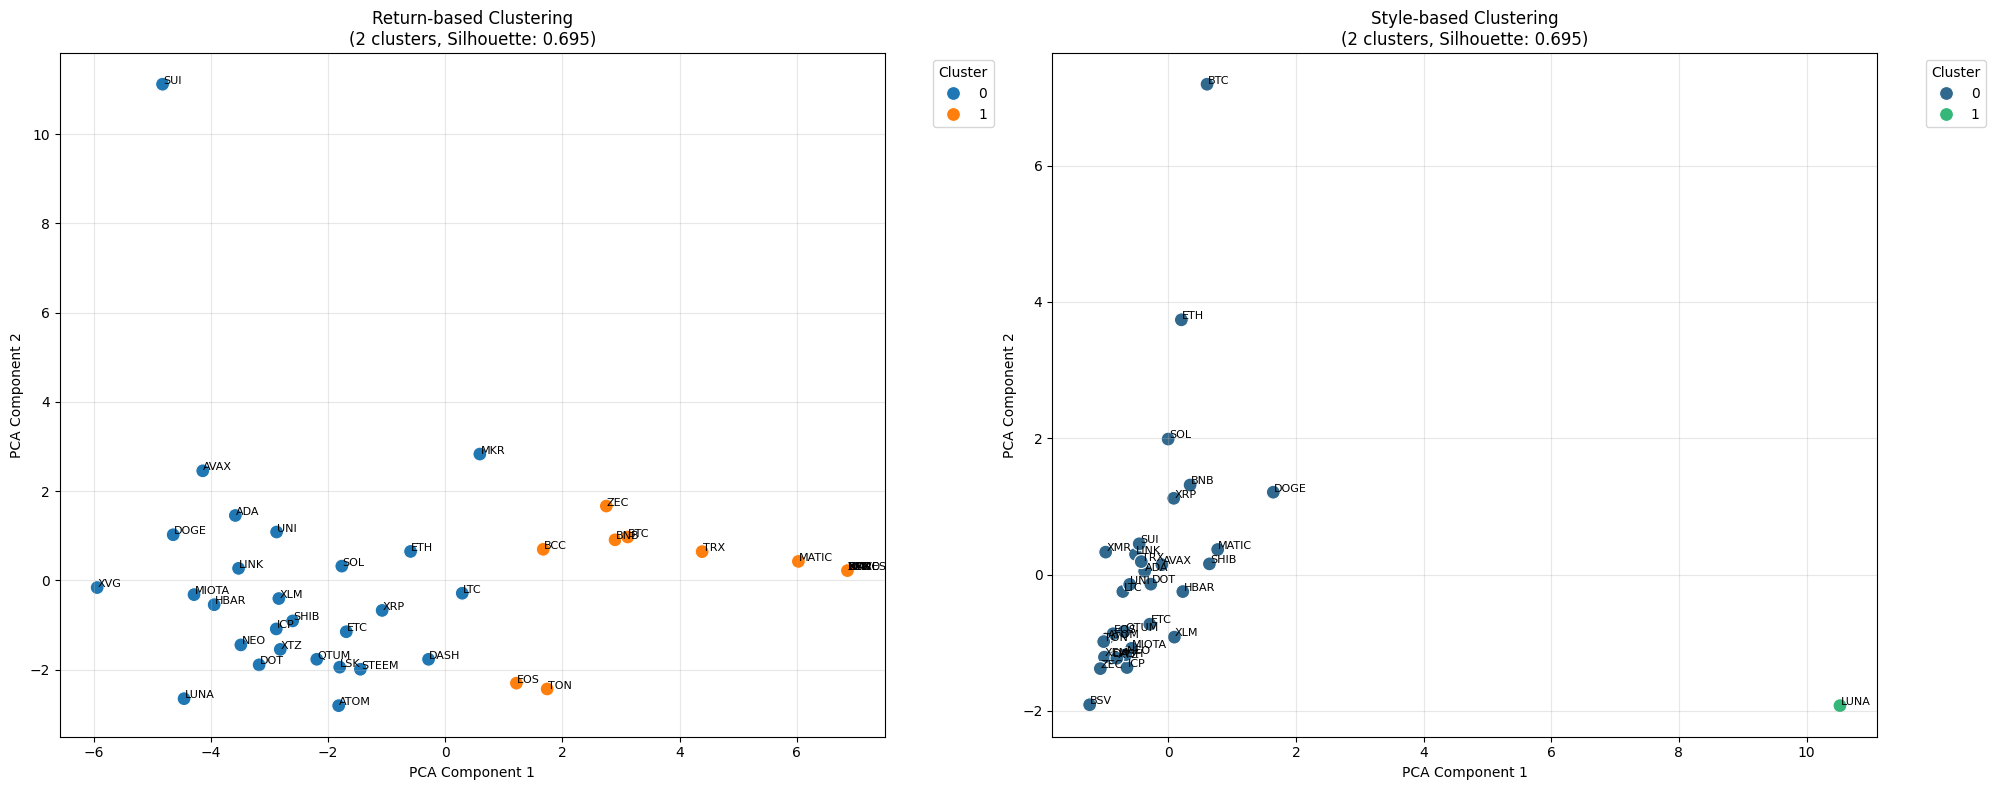

In [90]:
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Prepare data for return-based clustering
X_returns_pca = PCA(n_components=2).fit_transform(X_scaled)

# Create DataFrame for plotting
returns_plot_df = pd.DataFrame({
    'pca1': X_returns_pca[:, 0],
    'pca2': X_returns_pca[:, 1],
    'symbol': X.index,
    'cluster': res1['cluster'].values
})

# Plot return-based clustering
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Return-based clustering plot
sns.scatterplot(
    x='pca1', y='pca2',
    hue='cluster',
    data=returns_plot_df,
    palette='tab10',
    s=100,
    ax=axes[0]
)

# Add symbol labels for return-based
for i, row in returns_plot_df.iterrows():
    axes[0].text(row['pca1']+0.01, row['pca2']+0.01, row['symbol'], fontsize=8)

axes[0].set_title(f'Return-based Clustering\n({best_num_clusters} clusters, Silhouette: {best:.3f})')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

# Prepare data for style-based clustering
X_style_pca = PCA(n_components=2).fit_transform(X_style_scaled)

# Create DataFrame for plotting
style_plot_df = pd.DataFrame({
    'pca1': X_style_pca[:, 0],
    'pca2': X_style_pca[:, 1],
    'symbol': symbols.values,
    'cluster': res2['cluster'].values
})

# Plot style-based clustering
sns.scatterplot(
    x='pca1', y='pca2',
    hue='cluster',
    data=style_plot_df,
    palette='viridis',
    s=100,
    ax=axes[1]
)

# Add symbol labels for style-based
for i, row in style_plot_df.iterrows():
    axes[1].text(row['pca1']+0.01, row['pca2']+0.01, row['symbol'], fontsize=8)

axes[1].set_title(f'Style-based Clustering\n({best_num_clusters} clusters, Silhouette: {max(silhouette_scores):.3f})')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [92]:
import os
import pandas as pd
import numpy as np
import glob
import math
from scipy.stats import skew, kurtosis, jarque_bera
import statsmodels.api as sm
import statsmodels.tsa.stattools as st
import statsmodels.stats.diagnostic as ss
import matplotlib.pyplot as plt
import seaborn as sns
import imageio # Helps to generate a gif file

# Plot missing values in a dataframe
def plot_missing(df, filename):
    cmap = 'binary'
    plt.figure(figsize=(6,6))
    sns.heatmap(df.isnull(), cmap=cmap, cbar=False)
    plt.yticks([])
    plt.savefig(filename, transparent=True)
    plt.show()

# Define significance levels based on p-values
def level(pvalue):
    if pvalue < 0.01:
        return '***'
    elif pvalue < 0.05:
        return '**'
    elif pvalue < 0.1:
        return '*'
    else:
        return ''

# Compute statistics for each column in the dataframe
def compute_stat(df):
    stats_list = []
    for column in df.columns:
        column_stats = ['{:.5f}'.format(df[column].mean()),
                        '{:.4f}'.format(df[column].std()),
                        '{:.2f}'.format(skew(df[column].dropna())),
                        '{:.2f}'.format(kurtosis(df[column].dropna())),
                        '{:.2f}'.format(df[column].min()),
                        '{:.7f}'.format(df[column].median()),
                        '{:.4f}'.format(df[column].max()),
                        '{:.2f}'.format(jarque_bera(df[column].dropna())[0])+level(jarque_bera(df[column].dropna())[1])]
        stats_list.append(column_stats)
    stats_df = pd.DataFrame(stats_list, columns=['Mean', 'Std', 'Skew', 'Kurt', 'Min', '50%', 'Max', 'JB'], index=df.columns)
    return stats_df

# Plot correlation heatmap of the dataframe
def plot_corr(df, filename):
    corr = df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    cmap = 'bwr'
    plt.figure(figsize=(10,10))
    sns.heatmap(corr, cmap=cmap, center=0, annot=False, fmt=".2f", mask=mask, vmin=-1, vmax=1)
    plt.savefig(filename, transparent=True)
    plt.show()

# Plot boxplots of variables in the dataframe
def plot_boxplot(df, filename):
    plt.figure(figsize=(6, 6))
    sns.boxplot(data=df)
    plt.xticks(rotation=30)
    plt.savefig(filename, transparent=True)
    plt.show()

# Plot the time series of prices
def plot_timeseries(df, plot_type, filename):
    for column in df.columns:
        print(column)
        plt.figure(figsize=(10, 5))
        prices = df[column]
        plt.plot(prices, label=column)
        plt.xlabel('Date')
        plt.ylabel(plot_type)
        plt.title(column, fontsize=14, fontweight='bold')
        plt.savefig(filename+column+".png", transparent=True)
        plt.show()

# Plot the time series of prices (merge)
def plot_timeseries_merge(df, plot_type, num_column, filename):
    num_rows = math.ceil(len(df.columns) / num_column)
    fig, axes = plt.subplots(num_rows, num_column, figsize=(num_column*10, num_rows*5))
    fig.subplots_adjust(hspace=0.5)
    for i, column in enumerate(df.columns):
        row = i // num_column
        col = i % num_column
        ax = axes[row, col]
        prices = df[column]
        ax.plot(prices)
        ax.set_xlabel('Time')
        ax.set_ylabel(plot_type)
        ax.set_title(column, fontsize=14, fontweight='bold')
        if plot_type == "Price":
            ax.set_ylim(0, math.ceil(df.max().max()/100)*100)
        elif plot_type == "Return":
            ax.set_ylim(df.min().min(), df.max().max())
        else:
            ax.set_ylim(0, df.max().max())
    if len(df.columns) < num_rows * num_column:
        for i in range(len(df.columns), num_rows * num_column):
            fig.delaxes(axes.flatten()[i])
    plt.savefig(filename, transparent=True)
    plt.show()

def plot_timeseries_accumulative(df, filename):
    returns = df.pct_change()
    cumulative_returns = (1 + returns).cumprod() - 1
    plt.figure(figsize=(30, 15))
    for column in cumulative_returns.columns:
        color = next(plt.gca()._get_lines.prop_cycler)['color']
        plt.plot(cumulative_returns.index, cumulative_returns[column], label=column, color=color)
        last_value = cumulative_returns[column].iloc[-1]
        plt.text(cumulative_returns.index[-1] + np.timedelta64(200, 'D'), last_value, column,
        ha='left', va='center', color=color, fontsize=20, fontweight="bold")
    plt.xlabel('Date', fontsize=20)
    plt.ylabel('Cumulative Returns', fontsize=20)
    plt.title('Time Series of Cumulative Returns', fontsize=24, fontweight="bold")
    plt.legend(loc="upper left", fontsize=20)
    legend = plt.legend(loc="upper left", fontsize=20)
    legend.get_frame().set_alpha(0.0)
    start = cumulative_returns.index[0] - np.timedelta64(100, 'D')
    end = cumulative_returns.index[-1] + np.timedelta64(100, 'D')
    plt.xlim(start, end)
    plt.savefig(filename, transparent=True)
    plt.show()

def plot_rolling_corr_matrix(df, filename, window=120):
    num_stocks = len(df.columns)
    fig, axs = plt.subplots(num_stocks, num_stocks, figsize=(num_stocks*2, num_stocks))
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    for i in range(num_stocks):
        for j in range(num_stocks):
            if j < i:
                stock1 = df.columns[i]
                stock2 = df.columns[j]
                rolling_corr = df[stock1].rolling(window=window).corr(df[stock2])
                sns.lineplot(data=rolling_corr, ax=axs[i, j])
                axs[i, j].set_xlabel('')
                axs[i, j].set_ylabel('')
                axs[i, j].set_ylim(-1, 1)
            else:
                axs[i, j].axis('off')
    plt.tight_layout()
    plt.savefig(filename, transparent=True)
    plt.show()


In [ ]:
plot_timeseries(df, 'price', result_path + 'price_')